In [5]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from collections import deque, Counter

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [6]:

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)


In [7]:

dataset_dir = "asl_alphabet_train/asl_alphabet_train"


In [8]:

data = []

for label in os.listdir(dataset_dir):

    label_path = os.path.join(dataset_dir, label)

    if not os.path.isdir(label_path):
        continue

    print(f"Processing {label}...")

    for image_name in os.listdir(label_path):

        image_path = os.path.join(label_path, image_name)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        results = hands.process(image_rgb)

        if results.multi_hand_landmarks:

            for hand_landmarks in results.multi_hand_landmarks:

                landmarks = []

                base_x = hand_landmarks.landmark[0].x
                base_y = hand_landmarks.landmark[0].y
                base_z = hand_landmarks.landmark[0].z

                for lm in hand_landmarks.landmark:

                    landmarks.extend([
                        lm.x - base_x,
                        lm.y - base_y,
                        lm.z - base_z
                    ])

                if len(landmarks) == 63:

                    landmarks.append(label)

                    data.append(landmarks)

print("Feature Extraction Completed")




Processing A...
Processing B...
Processing C...
Processing D...
Processing del...
Processing E...
Processing F...
Processing G...
Processing H...
Processing I...
Processing J...
Processing K...
Processing L...
Processing M...
Processing N...
Processing nothing...
Processing O...
Processing P...
Processing Q...
Processing R...
Processing S...
Processing space...
Processing T...
Processing U...
Processing V...
Processing W...
Processing X...
Processing Y...
Processing Z...
Feature Extraction Completed


In [9]:

columns = [f"feature_{i}" for i in range(63)]
columns.append("label")

df = pd.DataFrame(data, columns=columns)

print(df.head())
print("Dataset Shape:", df.shape)


   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0        0.0        0.0        0.0   0.113358  -0.079893  -0.035579   
1        0.0        0.0        0.0   0.114493  -0.076812  -0.023035   
2        0.0        0.0        0.0   0.124374  -0.053135  -0.108801   
3        0.0        0.0        0.0   0.080084  -0.087506  -0.018448   
4        0.0        0.0        0.0   0.106636  -0.059591  -0.051515   

   feature_6  feature_7  feature_8  feature_9  ...  feature_54  feature_55  \
0   0.182703  -0.209345  -0.044406   0.194306  ...   -0.066242   -0.262248   
1   0.184967  -0.207021  -0.027995   0.198372  ...   -0.054786   -0.251769   
2   0.193082  -0.181252  -0.174243   0.203812  ...   -0.147173   -0.205321   
3   0.132361  -0.188259  -0.023330   0.147339  ...   -0.084133   -0.257294   
4   0.176198  -0.212423  -0.065128   0.170426  ...   -0.126210   -0.250841   

   feature_56  feature_57  feature_58  feature_59  feature_60  feature_61  \
0   -0.070151   -0.052481  

In [10]:

df.to_csv("dataset.csv", index=False)

print("CSV Dataset Saved Successfully")


CSV Dataset Saved Successfully


In [11]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72084 entries, 0 to 72083
Data columns (total 64 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   72084 non-null  float64
 1   feature_1   72084 non-null  float64
 2   feature_2   72084 non-null  float64
 3   feature_3   72084 non-null  float64
 4   feature_4   72084 non-null  float64
 5   feature_5   72084 non-null  float64
 6   feature_6   72084 non-null  float64
 7   feature_7   72084 non-null  float64
 8   feature_8   72084 non-null  float64
 9   feature_9   72084 non-null  float64
 10  feature_10  72084 non-null  float64
 11  feature_11  72084 non-null  float64
 12  feature_12  72084 non-null  float64
 13  feature_13  72084 non-null  float64
 14  feature_14  72084 non-null  float64
 15  feature_15  72084 non-null  float64
 16  feature_16  72084 non-null  float64
 17  feature_17  72084 non-null  float64
 18  feature_18  72084 non-null  float64
 19  feature_19  72084 non-nul

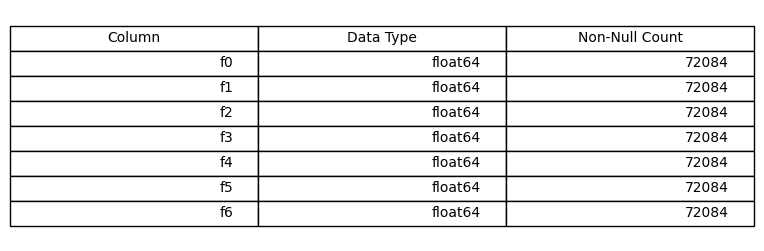

In [ ]:


# Create summary table from df.info()
info_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum().values
})

# Show first 7 rows
info_show = info_df.head(7)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=info_show.values,
    colLabels=info_show.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("df_info_table.png", bbox_inches='tight', dpi=300)
plt.show()

In [12]:

df.describe()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62
count,72084.0,72084.0,72084.0,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,...,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000,72084.000000
mean,0.0,0.0,0.0,0.075457,-0.055461,-0.049534,0.113255,-0.134964,-0.072080,0.085911,...,-0.039559,-0.121711,-0.239185,-0.080560,-0.103469,-0.214723,-0.079729,-0.089953,-0.194903,-0.068283
std,0.0,0.0,0.0,0.059829,0.047788,0.049365,0.122248,0.098340,0.070125,0.168912,...,0.052681,0.143115,0.147907,0.066832,0.160645,0.163457,0.065700,0.173778,0.182537,0.063816
min,0.0,0.0,0.0,-0.217545,-0.250163,-0.333772,-0.379249,-0.425829,-0.486671,-0.508680,...,-0.610475,-0.763988,-0.875877,-0.746321,-0.904665,-0.860289,-0.771549,-1.032535,-0.916582,-0.814417
25%,0.0,0.0,0.0,0.049163,-0.085328,-0.070119,0.052933,-0.198446,-0.099162,-0.006127,...,-0.055705,-0.202134,-0.331875,-0.108452,-0.181097,-0.313231,-0.107472,-0.158271,-0.296033,-0.094109
50%,0.0,0.0,0.0,0.081591,-0.059734,-0.045384,0.130039,-0.145540,-0.063342,0.092935,...,-0.033977,-0.100809,-0.245961,-0.072801,-0.076291,-0.208012,-0.070614,-0.061805,-0.166178,-0.058672
75%,0.0,0.0,0.0,0.111064,-0.030603,-0.028224,0.189648,-0.088118,-0.038714,0.195572,...,-0.016081,-0.049628,-0.153738,-0.043245,-0.034845,-0.129533,-0.042530,-0.026800,-0.099598,-0.032365
max,0.0,0.0,0.0,0.271650,0.175697,0.232278,0.459944,0.335347,0.320503,0.628068,...,0.312795,0.400396,0.543679,0.353082,0.516389,0.646125,0.378846,0.605295,0.749627,0.397614


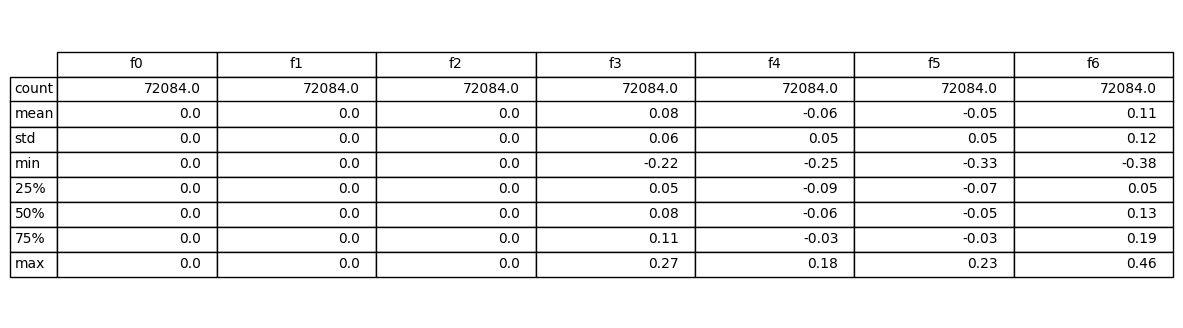

In [ ]:


# Describe data
desc = df.describe()

# Show first 7 columns only
desc_show = desc.iloc[:, :7]

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=desc_show.round(2).values,
    rowLabels=desc_show.index,
    colLabels=desc_show.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("df_describe_table.png", bbox_inches='tight', dpi=300)
plt.show()

In [13]:

df.isnull().sum()


feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
             ..
feature_59    0
feature_60    0
feature_61    0
feature_62    0
label         0
Length: 64, dtype: int64

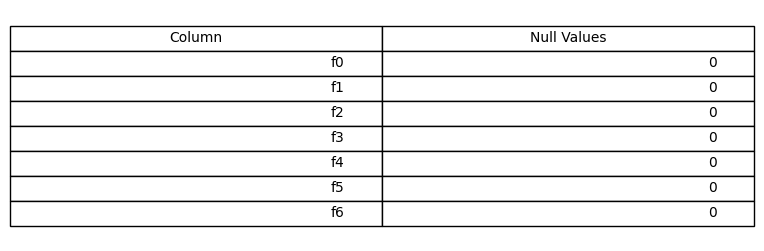

In [ ]:


# Null values count
null_df = pd.DataFrame({
    "Column": df.columns,
    "Null Values": df.isnull().sum().values
})

# Show first 7 rows
null_show = null_df.head(7)

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=null_show.values,
    colLabels=null_show.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("null_values_table.png", bbox_inches='tight', dpi=300)
plt.show()

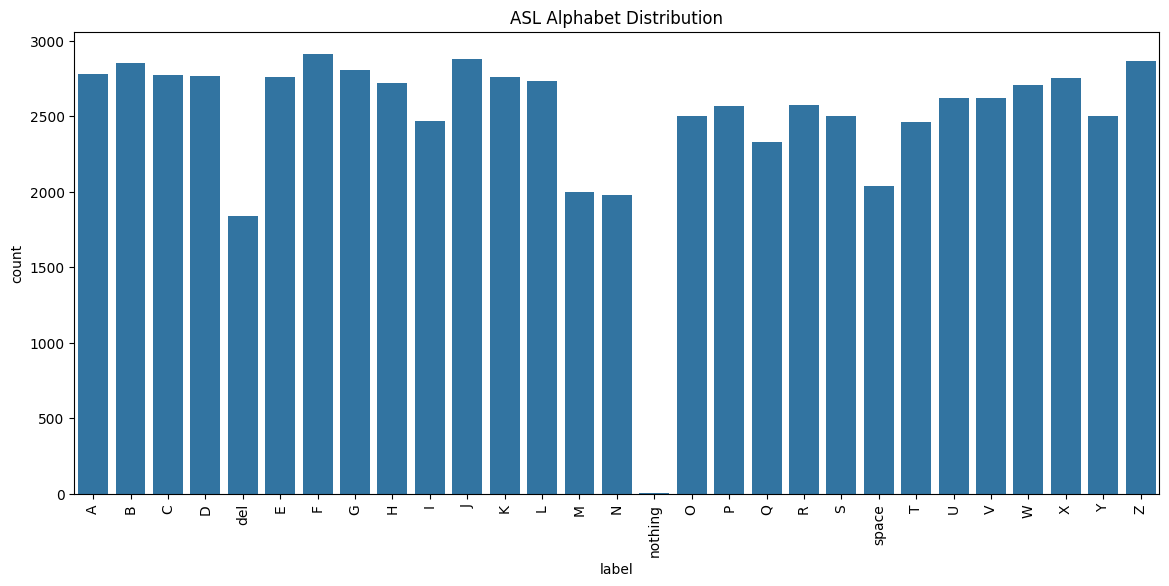

In [14]:

plt.figure(figsize=(14,6))

sns.countplot(x=df['label'])

plt.title("ASL Alphabet Distribution")
plt.xticks(rotation=90)
plt.show()


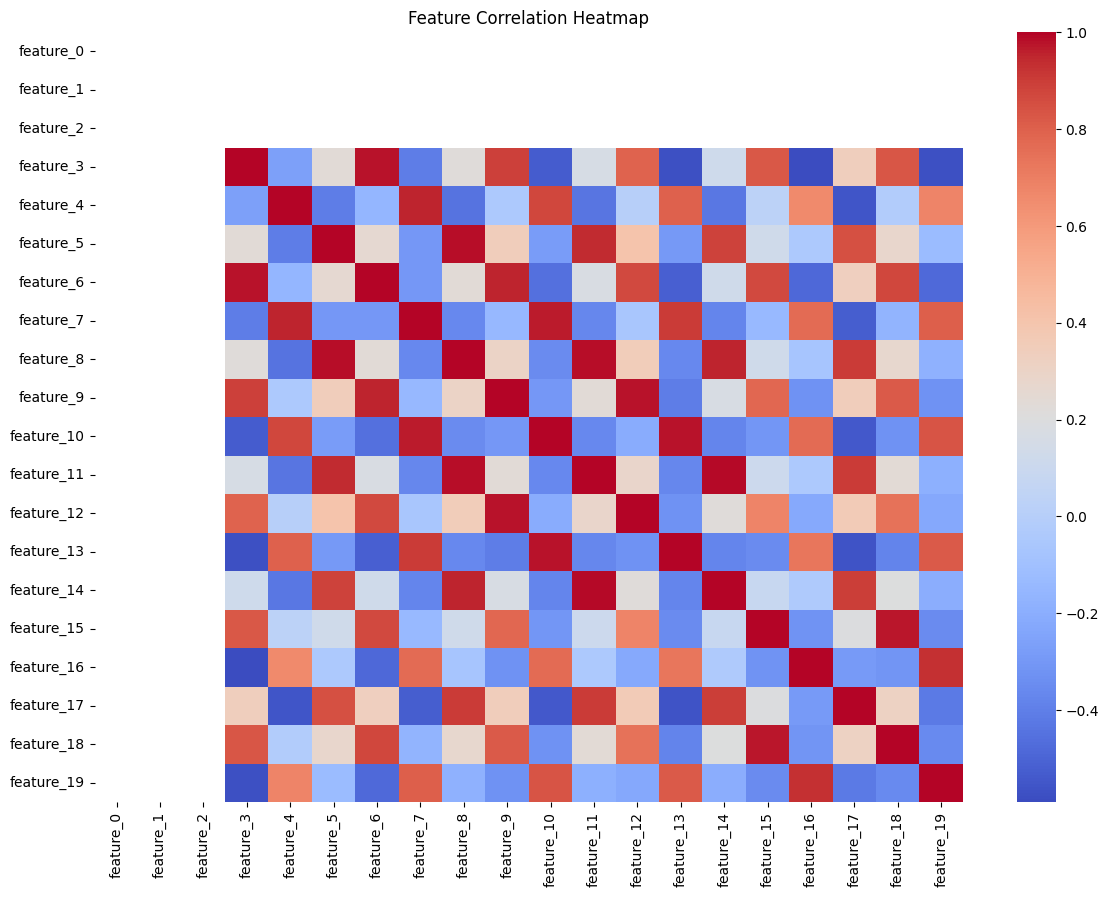

In [15]:

plt.figure(figsize=(14,10))

corr = df.iloc[:, :20].corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


In [16]:

X = df.drop("label", axis=1)
y = df["label"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (57667, 63)
Testing Shape: (14417, 63)


In [ ]:

from sklearn.metrics import accuracy_score

train_acc = []
val_acc = []
iterations = range(1, 11)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1,
    warm_start=True,
    random_state=42
)

for i in iterations:
    mlp.fit(X_train, y_train)

    train_pred = mlp.predict(X_train)
    val_pred = mlp.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_test, val_pred)

    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)

    print(f"Iteration {i}")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f}")

print("\nModel Training Completed")


c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1
  Train Accuracy: 0.9218
  Validation Accuracy: 0.9180


c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 2
  Train Accuracy: 0.9598
  Validation Accuracy: 0.9562


c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Iteration 8
  Train Accuracy: 0.9853
  Validation Accuracy: 0.9818


c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 9
  Train Accuracy: 0.9861
  Validation Accuracy: 0.9827


c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 10
  Train Accuracy: 0.9869
  Validation Accuracy: 0.9831

Model Training Completed


In [19]:

acc_df = pd.DataFrame({
    "Iteration": list(iterations),
    "Train Accuracy": [round(a, 4) for a in train_acc],
    "Validation Accuracy": [round(a, 4) for a in val_acc]
})

print(acc_df.to_string(index=False))


 Iteration  Train Accuracy  Validation Accuracy
         1          0.9218               0.9180
         2          0.9598               0.9562
         3          0.9719               0.9680
         4          0.9774               0.9741
         5          0.9810               0.9772
         6          0.9829               0.9793
         7          0.9840               0.9808
         8          0.9853               0.9818
         9          0.9861               0.9827
        10          0.9869               0.9831


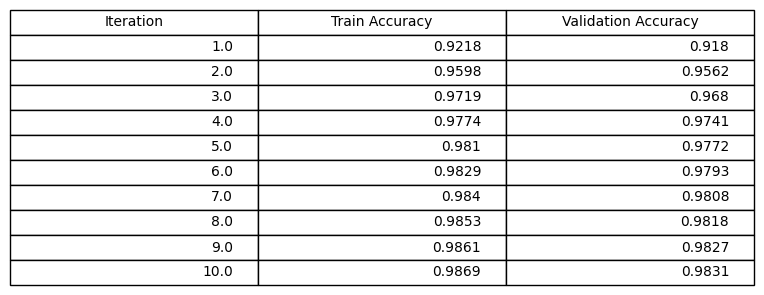

In [ ]:


# Create accuracy DataFrame
acc_df = pd.DataFrame({
    "Iteration": list(iterations),
    "Train Accuracy": [round(a, 4) for a in train_acc],
    "Validation Accuracy": [round(a, 4) for a in val_acc]
})

# Show table
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

table = ax.table(
    cellText=acc_df.values,
    colLabels=acc_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("accuracy_table.png", bbox_inches='tight', dpi=300)
plt.show()

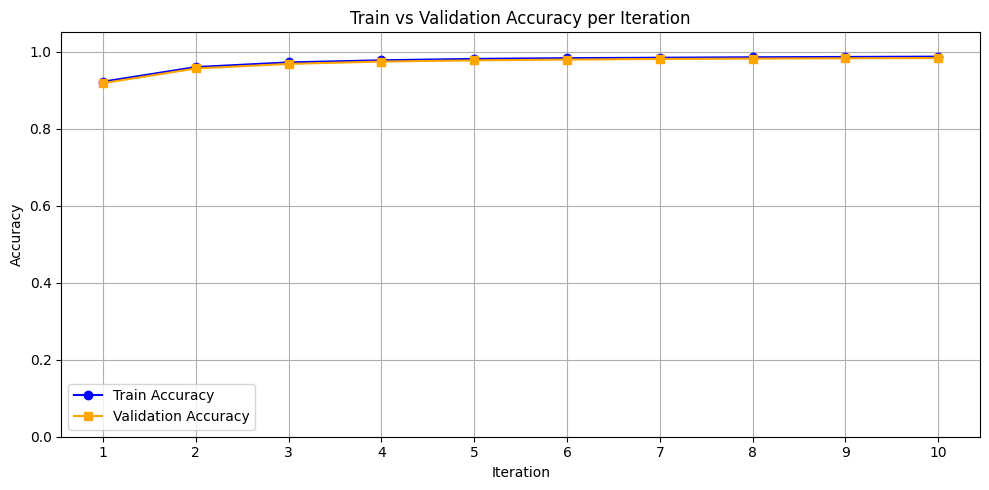

In [20]:

plt.figure(figsize=(10, 5))

plt.plot(list(iterations), train_acc, marker='o', label='Train Accuracy', color='blue')
plt.plot(list(iterations), val_acc, marker='s', label='Validation Accuracy', color='orange')

plt.title("Train vs Validation Accuracy per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.xticks(list(iterations))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:

y_pred = mlp.predict(X_test)


In [22]:

accuracy = accuracy_score(y_test, y_pred)

print("Final Test Accuracy:", accuracy)


Final Test Accuracy: 0.9830755358257612


In [23]:

report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
)

print(report)


              precision    recall  f1-score   support

           A       0.99      0.99      0.99       557
           B       1.00      1.00      1.00       570
           C       1.00      0.99      1.00       555
           D       1.00      0.98      0.99       553
           E       0.99      0.99      0.99       553
           F       0.99      0.99      0.99       583
           G       1.00      0.99      0.99       561
           H       0.99      0.99      0.99       544
           I       0.98      0.98      0.98       493
           J       0.99      0.99      0.99       576
           K       0.99      0.98      0.98       551
           L       0.99      0.99      0.99       547
           M       0.88      0.94      0.91       400
           N       0.94      0.89      0.91       396
           O       0.98      1.00      0.99       501
           P       0.99      0.98      0.99       514
           Q       0.98      0.97      0.98       466
           R       0.96    

c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\SignLanguageProject\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

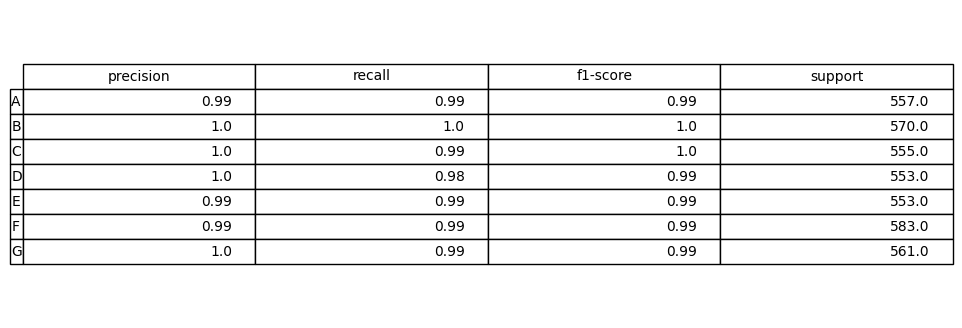

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Generate classification report as dictionary
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Show first 7 rows
report_show = report_df.head(7)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=report_show.round(2).values,
    rowLabels=report_show.index,
    colLabels=report_show.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("classification_report_table.png", bbox_inches='tight', dpi=300)
plt.show()

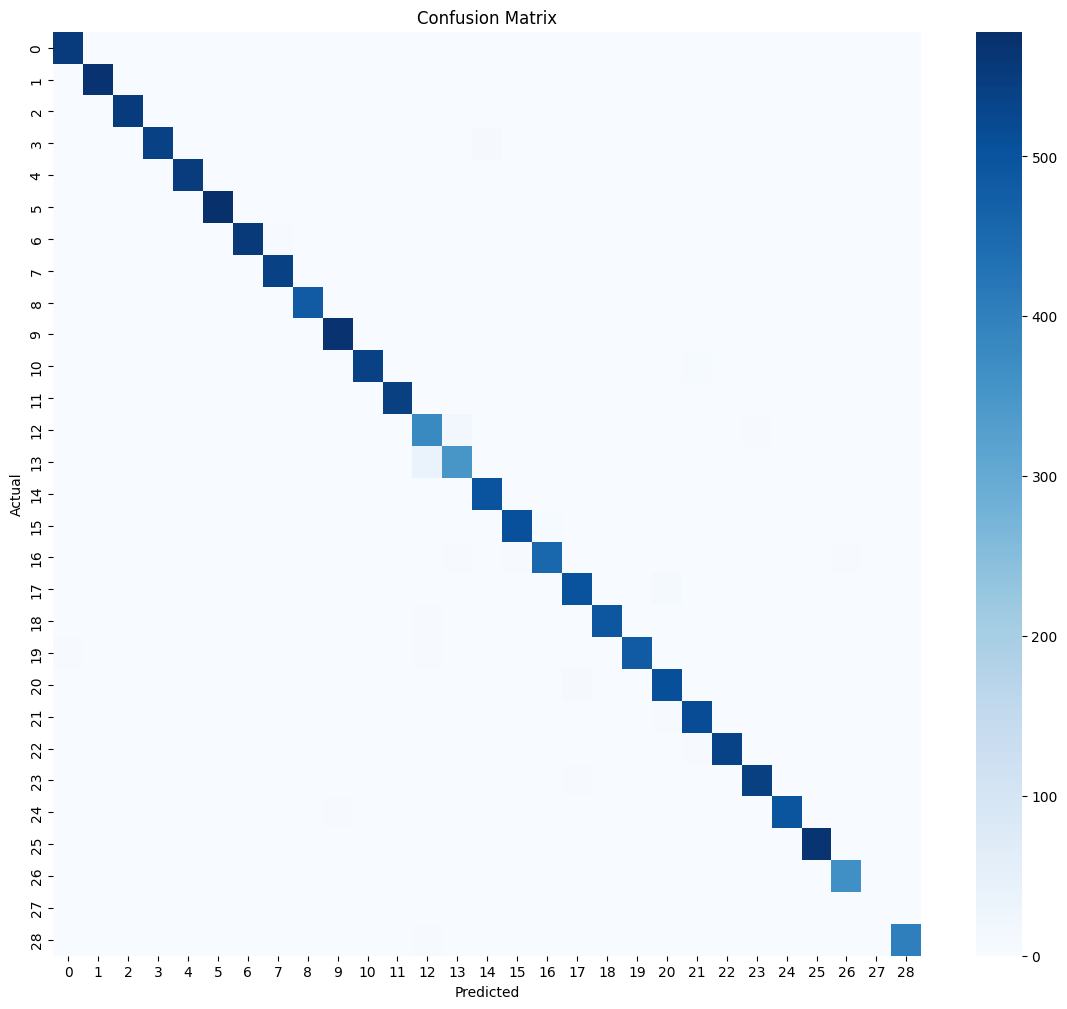

In [24]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


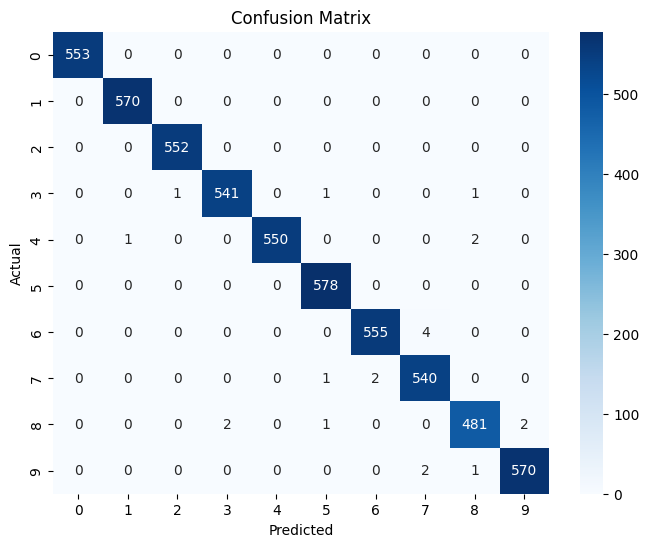

In [ ]:


# take first 10 classes (optional)
labels = sorted(set(y_test))[:10]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

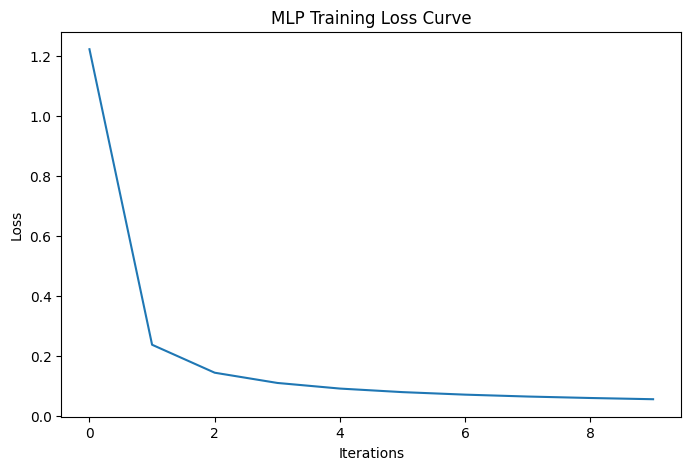

In [25]:

plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_)

plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()


In [26]:

def predict_image(image_path):

    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = hands.process(image_rgb)

    if results.multi_hand_landmarks:

        for hand_landmarks in results.multi_hand_landmarks:

            landmarks = []

            base_x = hand_landmarks.landmark[0].x
            base_y = hand_landmarks.landmark[0].y
            base_z = hand_landmarks.landmark[0].z

            for lm in hand_landmarks.landmark:

                landmarks.extend([
                    lm.x - base_x,
                    lm.y - base_y,
                    lm.z - base_z
                ])

            sample = np.array(landmarks).reshape(1, -1)

            sample = scaler.transform(sample)

            prediction = mlp.predict(sample)

            label = encoder.inverse_transform(prediction)

            print("Predicted Letter:", label[0])

# Example
# predict_image("test.jpg")


In [27]:
## Save model, scaler, encoder after training (add this in notebook)

import joblib

joblib.dump(mlp,     "model.pkl")
joblib.dump(scaler,  "scaler.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Saved successfully")

Saved successfully
